# 03 - Simulador de Vehículos Completo

**Pregunta de negocio:** ¿Podemos crear datos sintéticos realistas?

## Objetivos
- Usar `src/simulator/` para generar la flota completa
- Visualizar perfiles de vehículos y comparar tipos
- Generar telemetría y verificar correlaciones
- Guardar CSVs en `data/raw/`

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
sys.path.insert(0, project_root)

from src.simulator import VehicleProfileGenerator, TelemetryGenerator

## 1. Generación de perfiles de vehículos

In [2]:
vpg = VehicleProfileGenerator(seed=42)
fleet = vpg.generate_fleet(n_vehicles=50)

print(f"Flota: {len(fleet)} vehículos")
print(f"\nDistribución por tipo:")
print(fleet["vehicle_type"].value_counts())
fleet.head()

Flota: 50 vehículos

Distribución por tipo:
vehicle_type
gasolina     18
electrico    12
hibrido      12
deportivo     8
Name: count, dtype: int64


,vehicle_id,vehicle_type,fuel_type,model_year,motor_power_kw,max_speed_kmh,weight_kg,battery_capacity_kwh,tank_capacity_l,base_consumption_city,base_consumption_highway,co2_emissions_gkm
0,d49f49dc-dfbf-4e28-80e7-358e483a4319,electrico,electrico,2024,254.8,166.0,1566.0,98.5,NaN,17.15,21.58,0.0
1,f7b22da1-89bb-4a39-a495-0c1f36d6247b,electrico,electrico,2024,257.2,148.0,2149.0,78.6,NaN,14.70,18.97,0.0
2,b0cb327d-be57-43d3-9ec6-06af56178077,electrico,electrico,2021,264.6,167.0,1545.0,89.7,NaN,13.36,20.44,0.0
3,3992616c-f237-4c1e-8994-88e8de7ca36b,electrico,electrico,2023,251.6,161.0,2045.0,51.7,NaN,17.82,23.14,0.0
4,8604a5b4-bd08-4ad9-bcce-4131ddc0bbc1,electrico,electrico,2022,193.3,143.0,2021.0,98.1,NaN,12.93,21.46,0.0


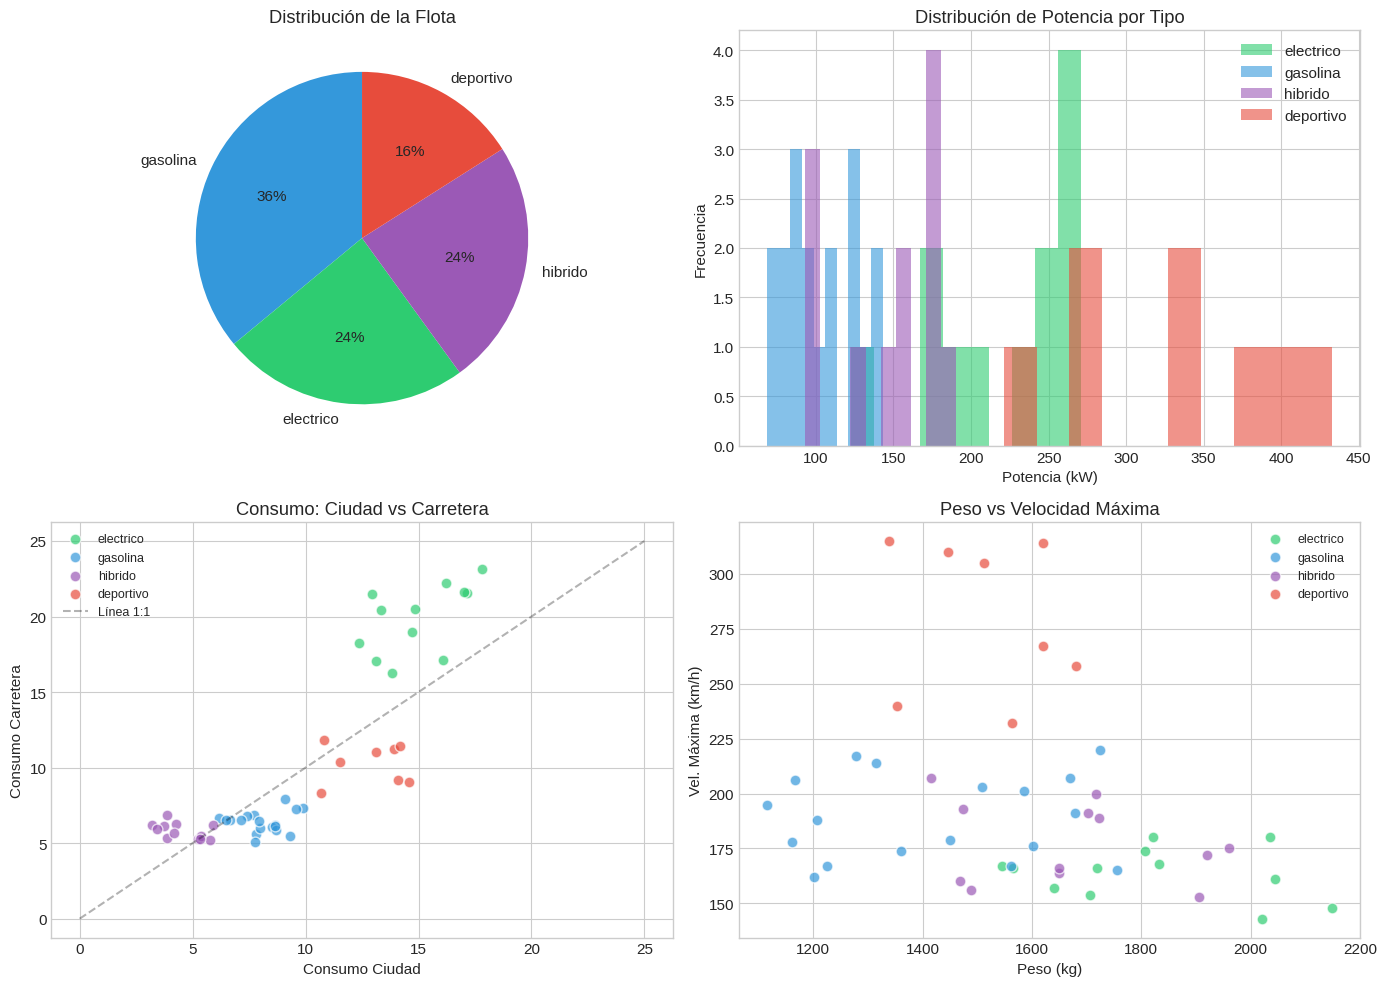

In [3]:
# Visualizar distribución de la flota
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = {'electrico': '#2ecc71', 'gasolina': '#3498db', 'hibrido': '#9b59b6', 'deportivo': '#e74c3c'}

# Distribución de tipos
tipo_counts = fleet['vehicle_type'].value_counts()
axes[0, 0].pie(tipo_counts.values, labels=tipo_counts.index, autopct='%1.0f%%',
               colors=[colors[t] for t in tipo_counts.index], startangle=90)
axes[0, 0].set_title('Distribución de la Flota')

# Potencia por tipo
for vtype in colors:
    subset = fleet[fleet['vehicle_type'] == vtype]
    axes[0, 1].hist(subset['motor_power_kw'], bins=10, alpha=0.6, color=colors[vtype], label=vtype)
axes[0, 1].set_xlabel('Potencia (kW)')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title('Distribución de Potencia por Tipo')
axes[0, 1].legend()

# Consumo ciudad vs carretera
for vtype in colors:
    subset = fleet[fleet['vehicle_type'] == vtype]
    axes[1, 0].scatter(subset['base_consumption_city'], subset['base_consumption_highway'],
                       color=colors[vtype], s=60, alpha=0.7, edgecolors='white', label=vtype)
axes[1, 0].plot([0, 25], [0, 25], 'k--', alpha=0.3, label='Línea 1:1')
axes[1, 0].set_xlabel('Consumo Ciudad')
axes[1, 0].set_ylabel('Consumo Carretera')
axes[1, 0].set_title('Consumo: Ciudad vs Carretera')
axes[1, 0].legend(fontsize=9)

# Peso vs velocidad máxima
for vtype in colors:
    subset = fleet[fleet['vehicle_type'] == vtype]
    axes[1, 1].scatter(subset['weight_kg'], subset['max_speed_kmh'],
                       color=colors[vtype], s=60, alpha=0.7, edgecolors='white', label=vtype)
axes[1, 1].set_xlabel('Peso (kg)')
axes[1, 1].set_ylabel('Vel. Máxima (km/h)')
axes[1, 1].set_title('Peso vs Velocidad Máxima')
axes[1, 1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 2. Telemetría individual: comparar estilos de conducción

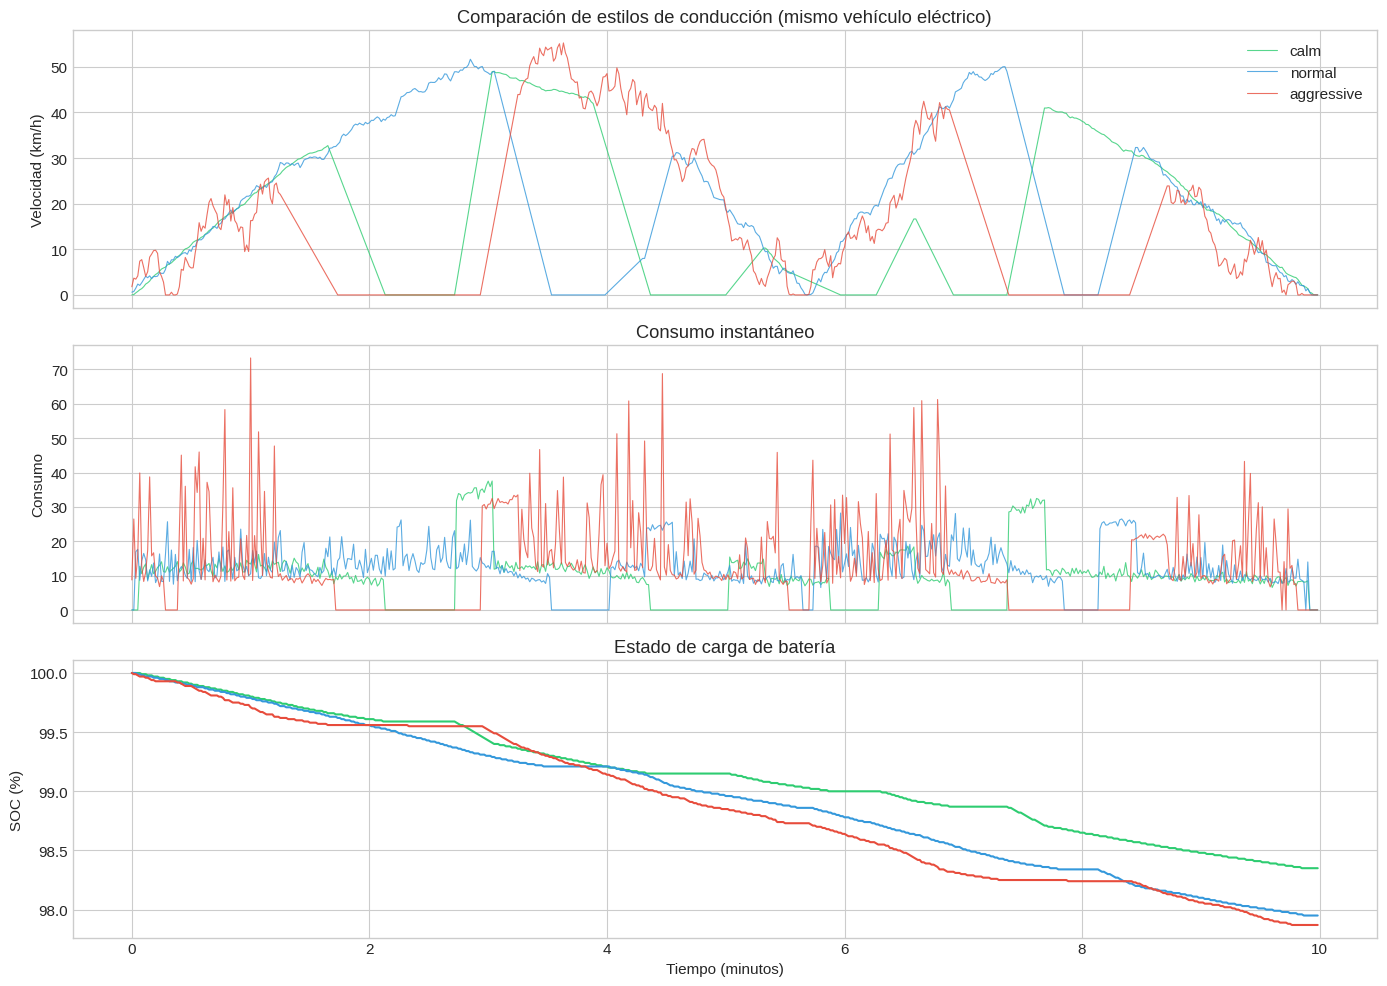

In [4]:
tg = TelemetryGenerator(seed=42)
ev = fleet[fleet['vehicle_type'] == 'electrico'].iloc[0]

# Generar viajes con 3 estilos
trips = {}
for style in ['calm', 'normal', 'aggressive']:
    trips[style] = tg.generate_trip_telemetry(
        vehicle_profile=ev.to_dict(),
        duration_seconds=600,
        driving_style=style,
        road_type='city',
    )

# Visualizar comparación
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
style_colors = {'calm': '#2ecc71', 'normal': '#3498db', 'aggressive': '#e74c3c'}

for style, trip in trips.items():
    t = np.arange(len(trip)) / 60  # minutos
    axes[0].plot(t, trip['speed_kmh'], linewidth=0.8, color=style_colors[style], alpha=0.8, label=style)
    axes[1].plot(t, trip['fuel_consumption_rate'], linewidth=0.8, color=style_colors[style], alpha=0.8, label=style)
    axes[2].plot(t, trip['battery_soc_pct'], linewidth=1.5, color=style_colors[style], label=style)

axes[0].set_ylabel('Velocidad (km/h)')
axes[0].set_title('Comparación de estilos de conducción (mismo vehículo eléctrico)')
axes[0].legend()

axes[1].set_ylabel('Consumo')
axes[1].set_title('Consumo instantáneo')

axes[2].set_ylabel('SOC (%)')
axes[2].set_title('Estado de carga de batería')
axes[2].set_xlabel('Tiempo (minutos)')

plt.tight_layout()
plt.show()

In [5]:
# Tabla comparativa
comparison = pd.DataFrame({
    style: {
        'vel_media': trip['speed_kmh'].mean(),
        'vel_std': trip['speed_kmh'].std(),
        'consumo_medio': trip['fuel_consumption_rate'].mean(),
        'caida_bateria_%': trip['battery_soc_pct'].iloc[0] - trip['battery_soc_pct'].iloc[-1],
    }
    for style, trip in trips.items()
}).T

print("Comparación numérica:")
comparison.round(2)

Comparación numérica:


,vel_media,vel_std,consumo_medio,caida_bateria_%
calm,16.20,15.31,9.76,1.65
normal,21.44,15.50,12.12,2.05
aggressive,15.48,15.96,12.59,2.13


## 3. Simulación completa de la flota

**NOTA:** Esta celda genera 50 vehículos × 30 días. Puede tardar varios minutos.
Para prueba rápida, reduce los valores.

In [6]:
from src.simulator import TripSimulator

sim = TripSimulator(seed=42, output_dir=os.path.join(project_root, "data/raw"))

results = sim.simulate(
    n_vehicles=50,
    n_days=30,
    n_surveys=500,
    start_date="2025-01-01",
    save_csv=True,
    verbose=True,
)

Generando flota de 50 vehículos...
Generando 500 encuestas...
Simulando 30 días de telemetría...
  Día 1/30 (2025-01-01)...
  Día 8/30 (2025-01-08)...
  Día 15/30 (2025-01-15)...
  Día 22/30 (2025-01-22)...
  Día 29/30 (2025-01-29)...
Telemetría total: 6,076,720 registros (3234 viajes)

Archivos guardados en /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/data/raw/
  - fleet_profiles.csv (50 vehículos)
  - surveys/buyer_surveys.csv (500 encuestas)
  - telemetry/telemetry_YYYY-MM-DD.csv (30 archivos diarios)


In [7]:
fleet_df = results["fleet"]
telemetry_df = results["telemetry"]
surveys_df = results["surveys"]

print(f"Flota: {len(fleet_df)} vehículos")
print(f"Telemetría: {len(telemetry_df):,} registros")
print(f"Encuestas: {len(surveys_df)} encuestas")
print(f"Memoria telemetría: {telemetry_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Flota: 50 vehículos
Telemetría: 6,076,720 registros
Encuestas: 500 encuestas
Memoria telemetría: 2006.1 MB


## 4. Verificación de correlaciones

/tmp/ipykernel_10666/4156165792.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(bp_data, labels=tipo_order, patch_artist=True)
/tmp/ipykernel_10666/4156165792.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[2].boxplot(bp_data2, labels=road_order, patch_artist=True)


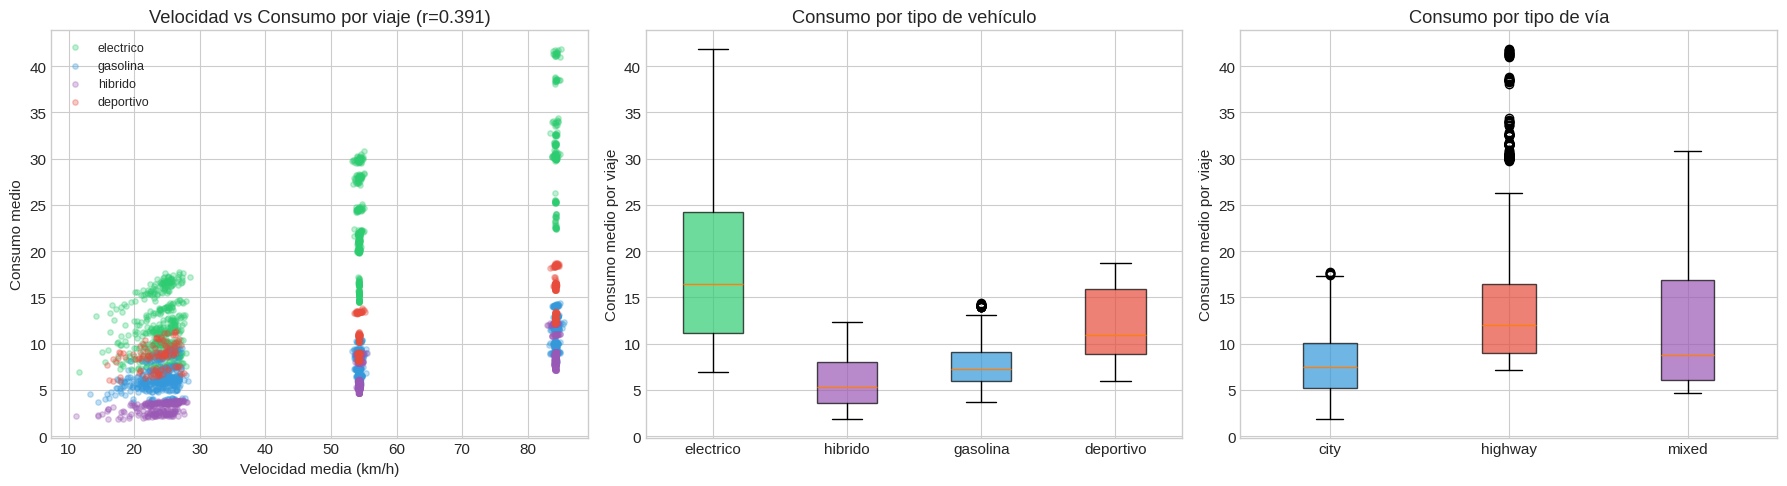


Consumo medio por tipo:
vehicle_type
deportivo    12.014
electrico    18.392
gasolina      7.830
hibrido       5.894
Name: consumption_mean, dtype: float64


In [8]:
# Agregar por viaje
tel_reset = telemetry_df.reset_index()
trip_stats = tel_reset.groupby("trip_id").agg(
    speed_mean=("speed_kmh", "mean"),
    consumption_mean=("fuel_consumption_rate", "mean"),
    vehicle_id=("vehicle_id", "first"),
    road_type=("road_type", "first"),
)
trip_stats = trip_stats.merge(fleet_df[["vehicle_id", "vehicle_type"]], on="vehicle_id")

# Visualizar correlaciones
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Velocidad vs Consumo (scatter por tipo)
for vtype in colors:
    subset = trip_stats[trip_stats['vehicle_type'] == vtype]
    axes[0].scatter(subset['speed_mean'], subset['consumption_mean'],
                    alpha=0.3, s=15, color=colors[vtype], label=vtype)
corr = trip_stats['speed_mean'].corr(trip_stats['consumption_mean'])
axes[0].set_xlabel('Velocidad media (km/h)')
axes[0].set_ylabel('Consumo medio')
axes[0].set_title(f'Velocidad vs Consumo por viaje (r={corr:.3f})')
axes[0].legend(fontsize=9)

# 2. Consumo por tipo de vehículo (boxplot)
tipo_order = ['electrico', 'hibrido', 'gasolina', 'deportivo']
bp_data = [trip_stats[trip_stats['vehicle_type'] == t]['consumption_mean'].dropna() for t in tipo_order]
bp = axes[1].boxplot(bp_data, labels=tipo_order, patch_artist=True)
for patch, vtype in zip(bp['boxes'], tipo_order):
    patch.set_facecolor(colors[vtype])
    patch.set_alpha(0.7)
axes[1].set_ylabel('Consumo medio por viaje')
axes[1].set_title('Consumo por tipo de vehículo')

# 3. Consumo por tipo de vía
road_colors = {'city': '#3498db', 'highway': '#e74c3c', 'mixed': '#9b59b6'}
road_order = ['city', 'highway', 'mixed']
bp_data2 = [trip_stats[trip_stats['road_type'] == r]['consumption_mean'].dropna() for r in road_order]
bp2 = axes[2].boxplot(bp_data2, labels=road_order, patch_artist=True)
for patch, road in zip(bp2['boxes'], road_order):
    patch.set_facecolor(road_colors[road])
    patch.set_alpha(0.7)
axes[2].set_ylabel('Consumo medio por viaje')
axes[2].set_title('Consumo por tipo de vía')

plt.tight_layout()
plt.show()

print("\nConsumo medio por tipo:")
print(trip_stats.groupby('vehicle_type')['consumption_mean'].mean().round(3))

In [9]:
# Verificar archivos guardados
data_dir = os.path.join(project_root, "data/raw")
print("Archivos generados:")
for root, dirs, files in os.walk(data_dir):
    level = root.replace(data_dir, "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 2 * (level + 1)
    for file in sorted(files)[:5]:
        size_kb = os.path.getsize(os.path.join(root, file)) / 1024
        print(f"{subindent}{file} ({size_kb:.1f} KB)")
    if len(files) > 5:
        print(f"{subindent}... y {len(files) - 5} archivos más")

Archivos generados:
raw/
  fleet_profiles.csv (5.1 KB)
  telemetry/
    telemetry_2025-01-01.csv (27828.5 KB)
    telemetry_2025-01-02.csv (34774.8 KB)
    telemetry_2025-01-03.csv (32731.9 KB)
    telemetry_2025-01-04.csv (31646.4 KB)
    telemetry_2025-01-05.csv (32069.0 KB)
    ... y 25 archivos más
  surveys/
    buyer_surveys.csv (84.0 KB)


## Resumen

### Respuesta a la pregunta de negocio:
> **¿Podemos crear datos sintéticos realistas?**
>
> Sí. Los datos muestran las correlaciones esperadas: mayor velocidad = mayor consumo,
> eléctricos consumen menos en ciudad, deportivos más en carretera, y el estilo
> agresivo impacta todas las métricas medibles.

### Siguiente notebook:
→ `04_survey_simulator.ipynb`: Encuestas de compradores